# Tech Challenge 5 - Indicador 9

- **Previsão de risco com Machine Learning:** Quais padrões nos
indicadores permitem identificar alunos em risco antes de queda no desempenho
ou aumento da defasagem? Construa um modelo preditivo que mostre uma
probabilidade do aluno ou aluna entrar em risco de defasagem.

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import SimpleImputer
import joblib

## Import dos Dados

In [91]:
df = pd.read_excel('/content/fat_datathon.xlsx')

colunas_selecao = ['ra','iaa_autoavaliacao', 'ida_desempenho_academico', 'ieg_engajamento_atividades',
        'ipp_psicopedagogicos', 'ian_adequacao_nivel', 'ips_aspectos_psicossociais', 'ipv_ponto_virada',
        'inde_indice_desen_educacional', 'requer_psicologia', 'atingiu_pv', 'defasagem', 'ano_arquivo']
df = df[colunas_selecao]

df.head()

,ra,iaa_autoavaliacao,ida_desempenho_academico,ieg_engajamento_atividades,ipp_psicopedagogicos,ian_adequacao_nivel,ips_aspectos_psicossociais,ipv_ponto_virada,inde_indice_desen_educacional,requer_psicologia,atingiu_pv,defasagem,ano_arquivo
0,RA-1,8.3,4.0,4.1,NaN,5.0,5.6,7.28,5.78,Requer avaliação,Não,-1.0,2022
1,RA-2,8.8,6.8,5.2,NaN,10.0,6.3,6.78,7.06,Sem limitações,Não,0.0,2022
2,RA-3,0.0,5.6,7.9,NaN,10.0,5.6,7.56,6.59,Sem limitações,Não,0.0,2022
3,RA-4,8.8,5.0,4.5,NaN,10.0,5.6,5.28,5.95,Requer avaliação,Não,0.0,2022
4,RA-5,7.9,5.2,8.6,NaN,10.0,5.6,7.39,7.43,Requer avaliação,Não,0.0,2022


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ra                             3030 non-null   object 
 1   iaa_autoavaliacao              2865 non-null   float64
 2   ida_desempenho_academico       2852 non-null   float64
 3   ieg_engajamento_atividades     2954 non-null   float64
 4   ipp_psicopedagogicos           1992 non-null   float64
 5   ian_adequacao_nivel            3030 non-null   float64
 6   ips_aspectos_psicossociais     2859 non-null   float64
 7   ipv_ponto_virada               2852 non-null   float64
 8   inde_indice_desen_educacional  1932 non-null   float64
 9   requer_psicologia              860 non-null    object 
 10  atingiu_pv                     860 non-null    object 
 11  defasagem                      860 non-null    float64
 12  ano_arquivo                    3030 non-null   i

In [93]:
df.shape

(3030, 13)

## Análise Exploratória

### Variáveis Quantitativas

In [94]:
colunas_quantitativas = ['iaa_autoavaliacao', 'ida_desempenho_academico', 'ieg_engajamento_atividades',
        'ipp_psicopedagogicos', 'ian_adequacao_nivel', 'ips_aspectos_psicossociais', 'ipv_ponto_virada',
        'inde_indice_desen_educacional','defasagem']

df[colunas_quantitativas].describe().round(2)

,iaa_autoavaliacao,ida_desempenho_academico,ieg_engajamento_atividades,ipp_psicopedagogicos,ian_adequacao_nivel,ips_aspectos_psicossociais,ipv_ponto_virada,inde_indice_desen_educacional,defasagem
count,2865.00,2852.00,2954.00,1992.00,3030.00,2859.00,2852.00,1932.00,860.00
mean,7.92,6.38,7.95,7.56,7.18,6.29,7.55,7.19,-0.94
std,2.63,1.96,2.15,0.94,2.54,1.79,1.08,0.95,0.85
min,0.00,0.00,0.00,2.50,2.50,2.50,2.50,3.03,-5.00
25%,7.90,5.10,7.30,7.08,5.00,5.02,6.98,6.67,-1.00
50%,8.75,6.67,8.60,7.50,5.00,7.50,7.58,7.31,-1.00
75%,9.50,7.83,9.40,8.13,10.00,7.51,8.26,7.86,0.00
max,10.00,10.00,10.00,10.00,10.00,10.00,10.01,9.44,2.00


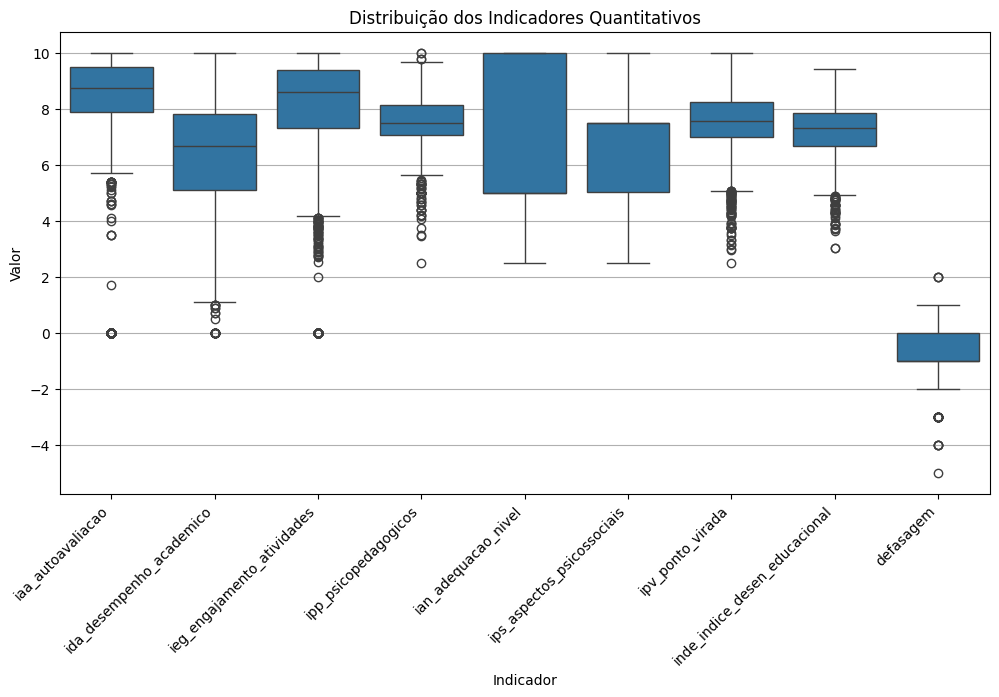

In [95]:
colunas_quantitativas = [
    'iaa_autoavaliacao',
    'ida_desempenho_academico',
    'ieg_engajamento_atividades',
    'ipp_psicopedagogicos',
    'ian_adequacao_nivel',
    'ips_aspectos_psicossociais',
    'ipv_ponto_virada',
    'inde_indice_desen_educacional',
    'defasagem'
]

# transforma para formato longo
df_long = df[colunas_quantitativas].melt(
    var_name="Indicador",
    value_name="Valor"
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_long, x="Indicador", y="Valor")
plt.xticks(rotation=45, ha="right")
plt.title("Distribuição dos Indicadores Quantitativos")
plt.grid(True, axis="y")

plt.show()

### Variáveis Qualitativas

In [96]:
colunas_qualitativas = ['requer_psicologia', 'atingiu_pv']

for coluna in colunas_qualitativas:
    print(f"\n\nDistribuição percentual da coluna: {coluna}\n")
    print(df[coluna].value_counts(normalize=True) * 100)



Distribuição percentual da coluna: requer_psicologia

requer_psicologia
Não atendido        47.209302
Sem limitações      29.534884
Requer avaliação    18.372093
Não indicado         4.302326
Não avaliado         0.581395
Name: proportion, dtype: float64


Distribuição percentual da coluna: atingiu_pv

atingiu_pv
Não    86.860465
Sim    13.139535
Name: proportion, dtype: float64


### Correlação

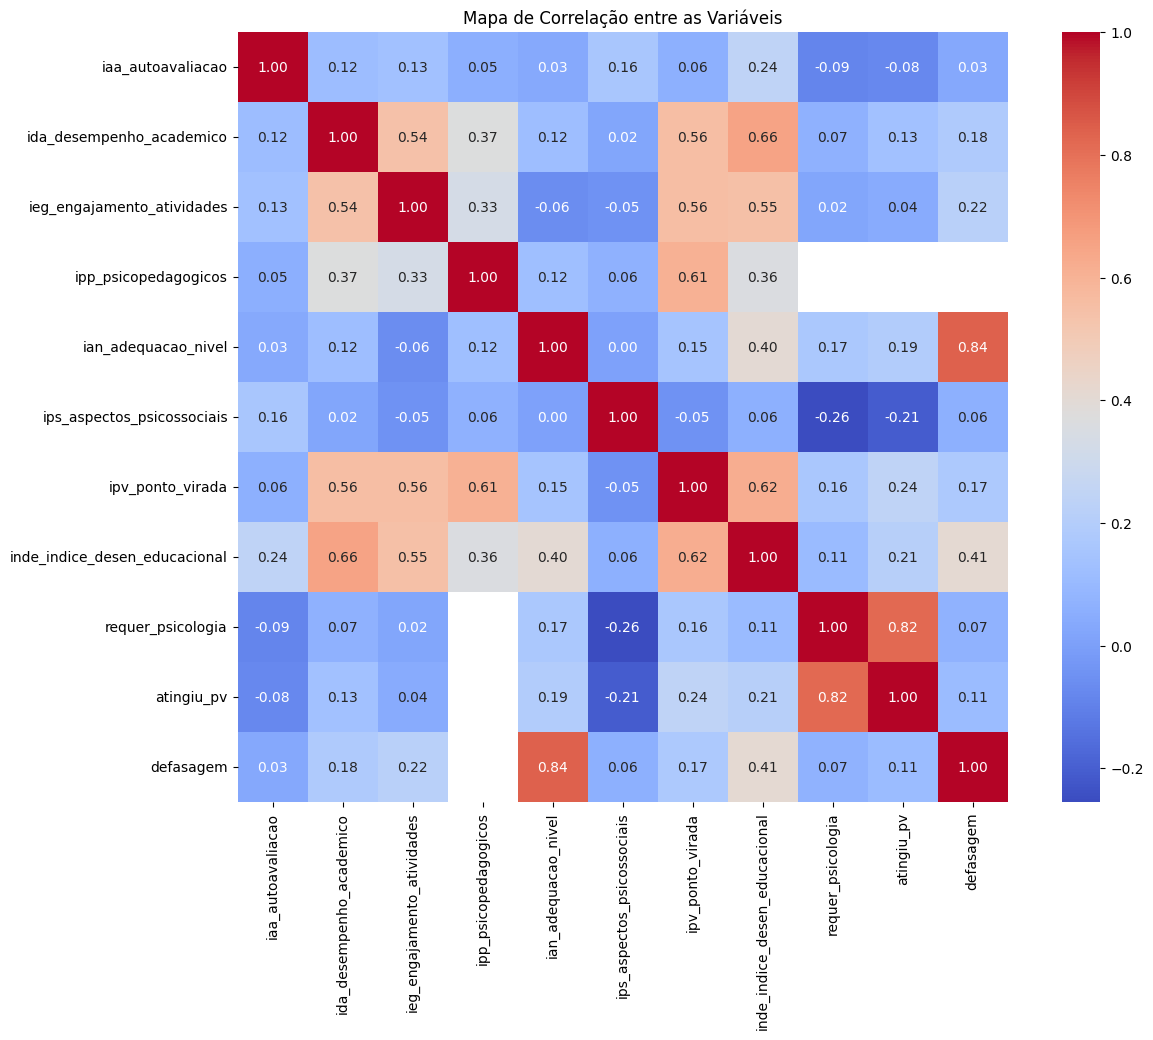

In [97]:
df_corr = df.copy().drop(columns=['ra','ano_arquivo'])

# Label Encoding nas colunas qualitativas
le = LabelEncoder()
for col in colunas_qualitativas:
    df_corr[col] = le.fit_transform(df_corr[col])

# Correlação
correlation_matrix = df_corr.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Mapa de Correlação entre as Variáveis")
plt.show()

## Criação da Variável Target

- risco = 1  se:
  - ida_desempenho_academico caiu no ano seguinte OU
  - defasagem aumentou no ano seguinte
- risco = 0  caso contrário

In [98]:
df = df.sort_values(by=["ra", "ano_arquivo"])

df["ida_next"] = df.groupby("ra")["ida_desempenho_academico"].shift(-1)
df["defasagem_next"] = df.groupby("ra")["defasagem"].shift(-1)

df["queda_ida"] = (df["ida_next"] < df["ida_desempenho_academico"]).astype(int)
df["aumento_defasagem"] = (df["defasagem_next"] < df["defasagem"]).astype(int)

df["risco"] = (
    (df["queda_ida"] == 1) |
    (df["aumento_defasagem"] == 1)
).astype(int)

In [99]:
df.drop(columns=["ida_next", "defasagem_next", "queda_ida", "aumento_defasagem"], inplace=True)

In [100]:
df.head(5)

,ra,iaa_autoavaliacao,ida_desempenho_academico,ieg_engajamento_atividades,ipp_psicopedagogicos,ian_adequacao_nivel,ips_aspectos_psicossociais,ipv_ponto_virada,inde_indice_desen_educacional,requer_psicologia,atingiu_pv,defasagem,ano_arquivo,risco
0,RA-1,8.3,4.0,4.1,NaN,5.0,5.6,7.28,5.78,Requer avaliação,Não,-1.0,2022,0
1855,RA-1,NaN,NaN,NaN,NaN,10.0,NaN,NaN,5.78,NaN,NaN,NaN,2023,0
2958,RA-1,NaN,NaN,0.0,NaN,10.0,NaN,NaN,5.78,NaN,NaN,NaN,2024,0
9,RA-10,8.3,4.1,5.2,NaN,5.0,5.0,7.06,5.78,Requer avaliação,Não,-1.0,2022,0
99,RA-100,8.8,7.6,7.8,NaN,10.0,5.0,7.25,7.62,Não indicado,Não,1.0,2022,0


In [101]:
df.to_csv('fat_datathon_tratado.csv', index=False)

## Pipeline

### Remover Colunas

In [102]:
# ['ra', 'ano_arquivo', 'requer_psicologia']

class DropFeatures(BaseEstimator, TransformerMixin):
  def __init__(self, feature_to_drop=['ra', 'ano_arquivo', 'requer_psicologia', 'ida_desempenho_academico', 'defasagem']):
    self.feature_to_drop = feature_to_drop

  def fit(self, df):
    return self

  def transform(self, df):
    if (set(self.feature_to_drop).issubset(df.columns)):
      df.drop(self.feature_to_drop, axis=1, inplace=True)
      return df
    else:
      print('Uma ou mais features não estão no DataFrame 1')
      return df

### Normalizar Colunas

In [103]:
# colunas_quantitativas = ['iaa_autoavaliacao', 'ida_desempenho_academico', 'ieg_engajamento_atividades',
#                          'ipp_psicopedagogicos', 'ian_adequacao_nivel', 'ips_aspectos_psicossociais',
#                          'ipv_ponto_virada', 'inde_indice_desen_educacional', 'defasagem']

colunas_quantitativas = ['iaa_autoavaliacao', 'ieg_engajamento_atividades',
                         'ipp_psicopedagogicos', 'ian_adequacao_nivel', 'ips_aspectos_psicossociais',
                         'ipv_ponto_virada', 'inde_indice_desen_educacional']

class MinMax(BaseEstimator, TransformerMixin):
    def __init__(self, min_max_scaler = colunas_quantitativas):
        self.min_max_scaler = min_max_scaler
        self.scaler = MinMaxScaler()

    def fit(self, df):
        if set(self.min_max_scaler).issubset(df.columns):
            self.scaler.fit(df[self.min_max_scaler])
        else:
            print("Uma ou mais features não estão no DataFrame")
        return self

    def transform(self, df):
        if set(self.min_max_scaler).issubset(df.columns):
            df[self.min_max_scaler] = self.scaler.transform(df[self.min_max_scaler])
            return df
        else:
            print("Uma ou mais features não estão no DataFrame")
            return df

### Codificar Variáveis Categóricas Nominais

In [104]:
class OneHotEncodingNames(BaseEstimator, TransformerMixin):
    def __init__(self, OneHotEncoding=['atingiu_pv']):
        self.OneHotEncoding = OneHotEncoding
        self.encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    def fit(self, df, y=None):
        # Fit apenas nas colunas categóricas
        self.encoder.fit(df[self.OneHotEncoding])
        return self

    def transform(self, df):
        if not set(self.OneHotEncoding).issubset(df.columns):
            print('Uma ou mais features não estão no DataFrame')
            return df

        # Transform sem refazer fit
        onehot_array = self.encoder.transform(df[self.OneHotEncoding])
        feature_names = self.encoder.get_feature_names_out(self.OneHotEncoding)

        df_onehot = pd.DataFrame(onehot_array, columns=feature_names, index=df.index)

        # Mantém colunas que não foram one-hot
        outras_features = df.drop(columns=self.OneHotEncoding)

        # Concatena
        df_final = pd.concat([df_onehot, outras_features], axis=1)

        return df_final

## Função Pipeline

- Separa treino e teste e aplica a pipeline

In [105]:
def preparar_dados(df, target='risco', ano_teste=2024, modo="producao"):

    df = df.sort_values(by=["ra", "ano_arquivo"]).copy()

    # 1️⃣ Comportamento diferente por modo

    if modo == "producao":
        # Remove rótulo do ano teste
        df.loc[df["ano_arquivo"] == ano_teste, target] = np.nan

    # 2️⃣ Split temporal

    df_train = df[df["ano_arquivo"] < ano_teste].copy()
    df_test  = df[df["ano_arquivo"] == ano_teste].copy()

    df_train = df_train.dropna(subset=[target])

    # 3️⃣ Separação X e y

    X_train = df_train.drop(columns=[target])
    y_train = df_train[target]

    if modo == "validacao":
        y_test = df_test[target]
        X_test = df_test.drop(columns=[target])
    else:
        y_test = None
        X_test = df_test.drop(columns=[target])

    # 4️⃣ Imputação Numérica

    colunas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns

    colunas_validas = [
        col for col in colunas_numericas
        if not X_train[col].isna().all()
    ]

    imputer = SimpleImputer(strategy='median')

    X_train[colunas_validas] = imputer.fit_transform(X_train[colunas_validas])
    X_test[colunas_validas]  = imputer.transform(X_test[colunas_validas])

    # 5️⃣ Pipeline

    pipe = Pipeline([
        ('Drop_feature', DropFeatures()),
        ('OneHotEncoding', OneHotEncodingNames()),
        ('min_max_scaler', MinMax())
    ])

    df_train_pipe = pd.concat([X_train, y_train], axis=1)
    df_train_transformed = pipe.fit_transform(df_train_pipe)

    df_test_transformed = pipe.transform(X_test)

    # 6️⃣ Separação final

    X_train_final = df_train_transformed.drop(columns=[target])
    y_train_final = df_train_transformed[target]

    X_test_final = df_test_transformed.copy()

    if modo == "validacao":
        X_train_final = X_train_final.drop(columns=['ipp_psicopedagogicos'])
        X_test_final = X_test_final.drop(columns=['ipp_psicopedagogicos'])

    return X_train_final, X_test_final, y_train_final, y_test, pipe


### Preparar dados Validação 2023

In [106]:
X_treino, X_teste, y_treino, y_teste, pipe = preparar_dados(
    df,
    ano_teste=2023,
    modo="validacao"
)

print(X_treino.shape)
print(X_teste.shape)
print(y_treino.shape)
print(y_teste.shape)

print()
print(y_treino.value_counts(normalize=True) * 100)
print()
print(y_teste.value_counts(normalize=True) * 100)

(860, 8)
(1014, 8)
(860,)
(1014,)

risco
0    66.511628
1    33.488372
Name: proportion, dtype: float64

risco
0    61.637081
1    38.362919
Name: proportion, dtype: float64


In [107]:
print("NaNs treino:", X_treino.isna().sum().sum())
print("NaNs teste:", X_teste.isna().sum().sum())

NaNs treino: 0
NaNs teste: 0


### Preparar dados Previsão 2024

In [108]:
X_treino_prev, X_teste_prev, y_treino_prev, y_teste_prev, pipe_prev = preparar_dados(
    df,
    ano_teste=2024,
    modo="producao"
)

print(X_treino_prev.shape)
print(X_teste_prev.shape)
print(y_treino_prev.shape)

print()
print(y_treino_prev.value_counts(normalize=True) * 100)

(1874, 10)
(1156, 10)
(1874,)

risco
0.0    63.874066
1.0    36.125934
Name: proportion, dtype: float64


In [109]:
print("NaNs treino:", X_treino_prev.isna().sum().sum())
print("NaNs teste:", X_teste_prev.isna().sum().sum())

NaNs treino: 0
NaNs teste: 0


In [110]:
X_treino_prev.head(5)

,atingiu_pv_Não,atingiu_pv_Sim,atingiu_pv_nan,iaa_autoavaliacao,ieg_engajamento_atividades,ipp_psicopedagogicos,ian_adequacao_nivel,ips_aspectos_psicossociais,ipv_ponto_virada,inde_indice_desen_educacional
0,1.0,0.0,0.0,0.83,0.41,0.647351,0.333333,0.413333,0.636485,0.429017
1855,0.0,0.0,1.0,0.85,0.87,0.647351,1.000000,0.586667,0.689747,0.429017
9,1.0,0.0,0.0,0.83,0.52,0.647351,0.333333,0.333333,0.607190,0.429017
99,1.0,0.0,0.0,0.88,0.78,0.647351,1.000000,0.333333,0.632490,0.716069
1072,0.0,0.0,1.0,0.85,0.94,0.413907,1.000000,0.169333,0.854860,0.663027


## Modelos

### Função Validação

In [111]:
# SEED = 42

def roda_modelo(modelo):

  modelo.fit(X_treino, y_treino)
  prob_predic = modelo.predict_proba(X_teste)

  print(f"\n------------------------------Resultados {modelo}------------------------------\n")

  # Calculate AUC for multiclass
  auc = roc_auc_score(y_teste, prob_predic[:, 1])
  print(f"AUC: {auc}")


  print("\nConfusion Matrix\n")

  # Criando matriz de confusão
  fix, ax = plt.subplots(figsize=(10,10))
  matriz_confusao = ConfusionMatrixDisplay.from_estimator(modelo, X_teste, y_teste, normalize='true',
                                                          ax=ax, cmap=plt.cm.Blues, values_format=".2f")

  ax.set_title("Matriz de Confusão\n Normalizada", fontsize=16, fontweight="bold")
  ax.set_xlabel("Label predita", fontsize=18)
  ax.set_ylabel("Label verdadeira", fontsize=18)
  plt.xticks(rotation=90)
  plt.yticks(rotation=0)
  plt.show(matriz_confusao)


  # Fazendo a predição dos dados de teste e calculando o classification report
  predicao = modelo.predict(X_teste)

  print("\nClassification Report")
  print(classification_report(y_teste, predicao, zero_division=0))


### Função Previsão

In [112]:
def prever_risco(modelo):

    modelo.fit(X_treino_prev, y_treino_prev)

    prob_predic = modelo.predict_proba(X_teste_prev)[:, 1]

    df_resultado = X_teste_prev.copy()
    df_resultado["prob_risco"] = prob_predic

    print(f"\n------------------------------Previsão {modelo}------------------------------\n")

    print("Distribuição das probabilidades:")
    print(df_resultado["prob_risco"].describe())

    return df_resultado


### Regressão Logística

In [113]:
from sklearn.linear_model import LogisticRegression
modelo_logistico = LogisticRegression()


------------------------------Resultados LogisticRegression()------------------------------

AUC: 0.5949614395886889

Confusion Matrix



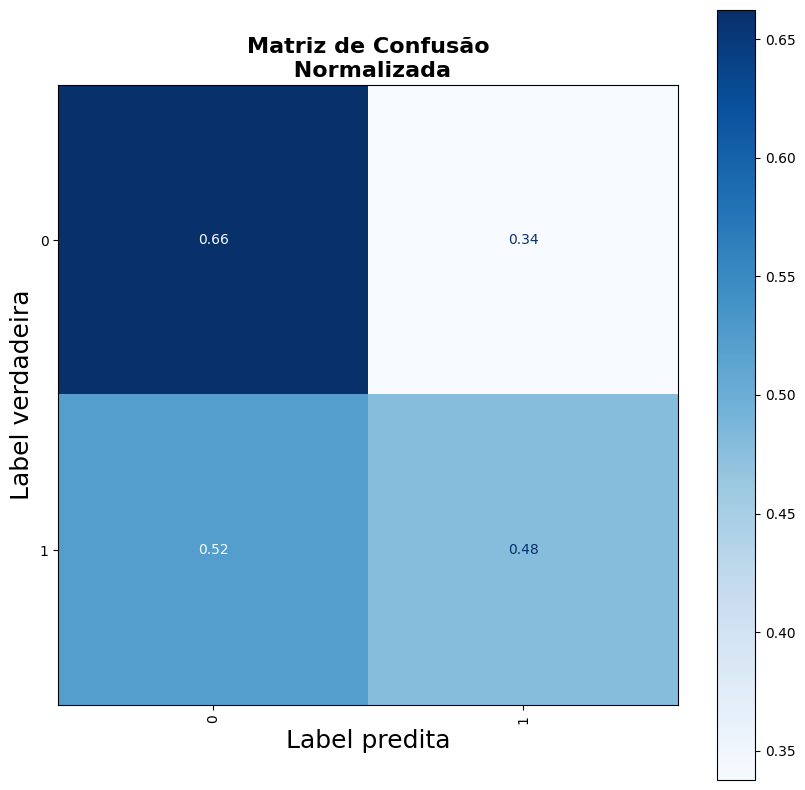


Classification Report
              precision    recall  f1-score   support

           0       0.67      0.66      0.67       625
           1       0.47      0.48      0.47       389

    accuracy                           0.59      1014
   macro avg       0.57      0.57      0.57      1014
weighted avg       0.59      0.59      0.59      1014



In [114]:
roda_modelo(modelo_logistico)

In [115]:
prever_risco(modelo_logistico)


------------------------------Previsão LogisticRegression()------------------------------

Distribuição das probabilidades:
count    1156.000000
mean        0.281908
std         0.132236
min         0.018211
25%         0.182594
50%         0.295366
75%         0.383593
max         0.637699
Name: prob_risco, dtype: float64


,atingiu_pv_Não,atingiu_pv_Sim,atingiu_pv_nan,iaa_autoavaliacao,ieg_engajamento_atividades,ipp_psicopedagogicos,ian_adequacao_nivel,ips_aspectos_psicossociais,ipv_ponto_virada,inde_indice_desen_educacional,prob_risco
2958,0.0,0.0,1.0,0.85,0.000,0.647351,1.000000,0.586667,0.689747,0.429017,0.026709
2225,0.0,0.0,1.0,0.90,0.955,0.725166,1.000000,0.501333,0.711052,0.663027,0.305191
2227,0.0,0.0,1.0,0.75,0.935,0.690397,0.333333,0.668000,0.721704,0.663027,0.442337
2001,0.0,0.0,1.0,0.90,0.783,0.620861,0.333333,0.668000,0.765646,0.663027,0.356852
1949,0.0,0.0,1.0,0.80,0.869,0.518212,0.333333,0.668000,0.665779,0.663027,0.378115
...,...,...,...,...,...,...,...,...,...,...,...
2246,0.0,0.0,1.0,0.95,0.786,0.569536,1.000000,0.501333,0.537949,0.663027,0.191951
2070,0.0,0.0,1.0,0.95,0.750,0.776490,0.333333,0.668000,0.777630,0.663027,0.347803
2072,0.0,0.0,1.0,0.90,0.818,0.620861,0.333333,0.501333,0.561917,0.663027,0.342158
2051,0.0,0.0,1.0,0.90,0.953,0.518212,0.333333,0.584000,0.643142,0.663027,0.417051


### Árvore de Decisão

In [116]:
from sklearn.tree import DecisionTreeClassifier
modelo_tree = DecisionTreeClassifier()


------------------------------Resultados DecisionTreeClassifier()------------------------------

AUC: 0.5191917737789203

Confusion Matrix



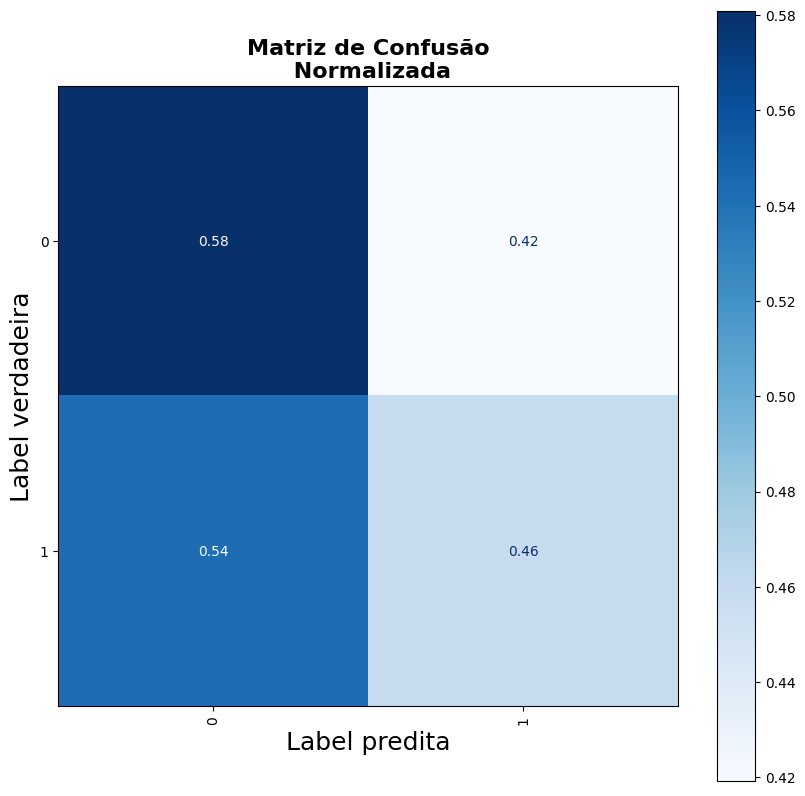


Classification Report
              precision    recall  f1-score   support

           0       0.63      0.58      0.61       625
           1       0.40      0.46      0.43       389

    accuracy                           0.53      1014
   macro avg       0.52      0.52      0.52      1014
weighted avg       0.54      0.53      0.54      1014



In [117]:
roda_modelo(modelo_tree)

In [118]:
prever_risco(modelo_tree)


------------------------------Previsão DecisionTreeClassifier()------------------------------

Distribuição das probabilidades:
count    1156.000000
mean        0.397059
std         0.489500
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: prob_risco, dtype: float64


,atingiu_pv_Não,atingiu_pv_Sim,atingiu_pv_nan,iaa_autoavaliacao,ieg_engajamento_atividades,ipp_psicopedagogicos,ian_adequacao_nivel,ips_aspectos_psicossociais,ipv_ponto_virada,inde_indice_desen_educacional,prob_risco
2958,0.0,0.0,1.0,0.85,0.000,0.647351,1.000000,0.586667,0.689747,0.429017,0.0
2225,0.0,0.0,1.0,0.90,0.955,0.725166,1.000000,0.501333,0.711052,0.663027,1.0
2227,0.0,0.0,1.0,0.75,0.935,0.690397,0.333333,0.668000,0.721704,0.663027,1.0
2001,0.0,0.0,1.0,0.90,0.783,0.620861,0.333333,0.668000,0.765646,0.663027,1.0
1949,0.0,0.0,1.0,0.80,0.869,0.518212,0.333333,0.668000,0.665779,0.663027,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2246,0.0,0.0,1.0,0.95,0.786,0.569536,1.000000,0.501333,0.537949,0.663027,0.0
2070,0.0,0.0,1.0,0.95,0.750,0.776490,0.333333,0.668000,0.777630,0.663027,1.0
2072,0.0,0.0,1.0,0.90,0.818,0.620861,0.333333,0.501333,0.561917,0.663027,1.0
2051,0.0,0.0,1.0,0.90,0.953,0.518212,0.333333,0.584000,0.643142,0.663027,0.0


### Random Forest

In [119]:
from sklearn.ensemble import RandomForestClassifier
modelo_forest = RandomForestClassifier(random_state=42)


------------------------------Resultados RandomForestClassifier(random_state=42)------------------------------

AUC: 0.5918066838046272

Confusion Matrix



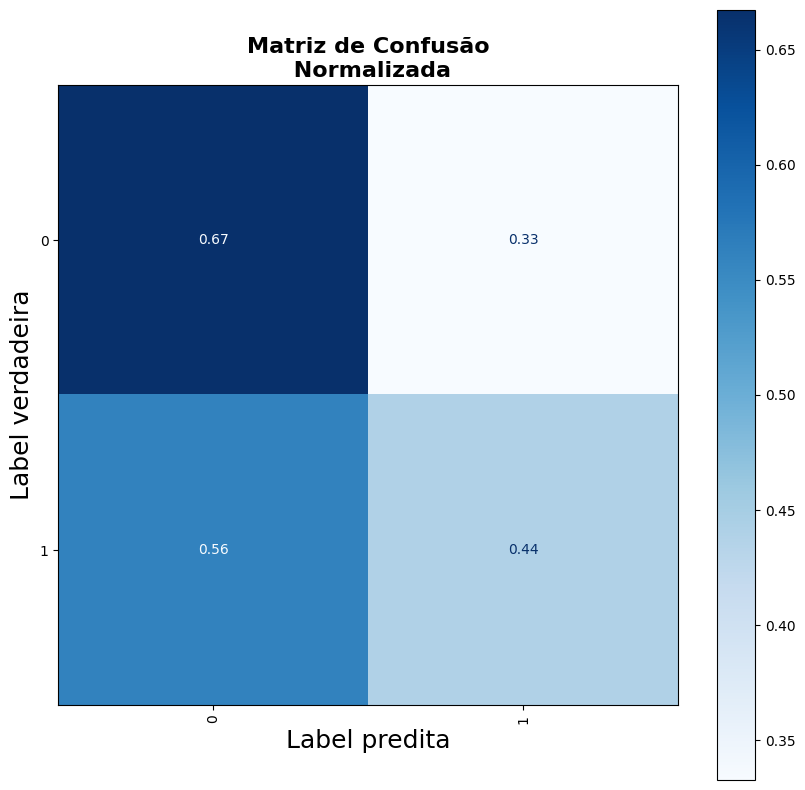


Classification Report
              precision    recall  f1-score   support

           0       0.66      0.67      0.66       625
           1       0.45      0.44      0.45       389

    accuracy                           0.58      1014
   macro avg       0.55      0.55      0.55      1014
weighted avg       0.58      0.58      0.58      1014



In [120]:
roda_modelo(modelo_forest)

In [121]:
prever_risco(modelo_forest)


------------------------------Previsão RandomForestClassifier(random_state=42)------------------------------

Distribuição das probabilidades:
count    1156.000000
mean        0.349187
std         0.167730
min         0.020000
25%         0.220000
50%         0.350000
75%         0.480000
max         0.820000
Name: prob_risco, dtype: float64


,atingiu_pv_Não,atingiu_pv_Sim,atingiu_pv_nan,iaa_autoavaliacao,ieg_engajamento_atividades,ipp_psicopedagogicos,ian_adequacao_nivel,ips_aspectos_psicossociais,ipv_ponto_virada,inde_indice_desen_educacional,prob_risco
2958,0.0,0.0,1.0,0.85,0.000,0.647351,1.000000,0.586667,0.689747,0.429017,0.06
2225,0.0,0.0,1.0,0.90,0.955,0.725166,1.000000,0.501333,0.711052,0.663027,0.66
2227,0.0,0.0,1.0,0.75,0.935,0.690397,0.333333,0.668000,0.721704,0.663027,0.29
2001,0.0,0.0,1.0,0.90,0.783,0.620861,0.333333,0.668000,0.765646,0.663027,0.67
1949,0.0,0.0,1.0,0.80,0.869,0.518212,0.333333,0.668000,0.665779,0.663027,0.15
...,...,...,...,...,...,...,...,...,...,...,...
2246,0.0,0.0,1.0,0.95,0.786,0.569536,1.000000,0.501333,0.537949,0.663027,0.37
2070,0.0,0.0,1.0,0.95,0.750,0.776490,0.333333,0.668000,0.777630,0.663027,0.55
2072,0.0,0.0,1.0,0.90,0.818,0.620861,0.333333,0.501333,0.561917,0.663027,0.54
2051,0.0,0.0,1.0,0.90,0.953,0.518212,0.333333,0.584000,0.643142,0.663027,0.30


### Gradient Boosting Classifier

In [122]:
from sklearn.ensemble import GradientBoostingClassifier
modelo_xgb = GradientBoostingClassifier()


------------------------------Resultados GradientBoostingClassifier()------------------------------

AUC: 0.5501388174807198

Confusion Matrix



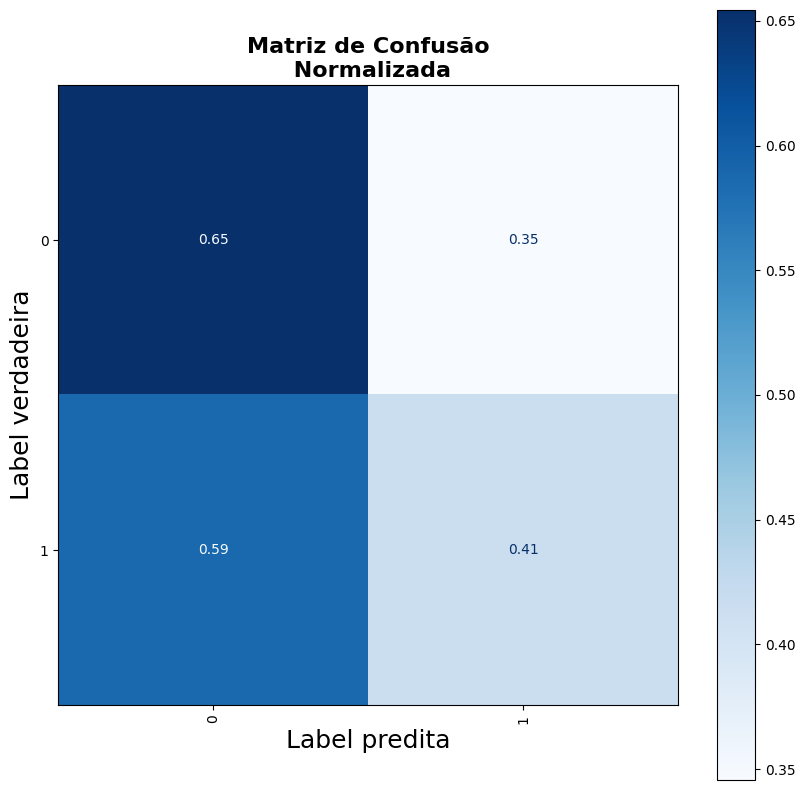


Classification Report
              precision    recall  f1-score   support

           0       0.64      0.65      0.65       625
           1       0.43      0.41      0.42       389

    accuracy                           0.56      1014
   macro avg       0.53      0.53      0.53      1014
weighted avg       0.56      0.56      0.56      1014



In [123]:
roda_modelo(modelo_xgb)

In [124]:
prever_risco(modelo_xgb)


------------------------------Previsão GradientBoostingClassifier()------------------------------

Distribuição das probabilidades:
count    1156.000000
mean        0.323309
std         0.148323
min         0.013178
25%         0.205916
50%         0.313350
75%         0.422613
max         0.918621
Name: prob_risco, dtype: float64


,atingiu_pv_Não,atingiu_pv_Sim,atingiu_pv_nan,iaa_autoavaliacao,ieg_engajamento_atividades,ipp_psicopedagogicos,ian_adequacao_nivel,ips_aspectos_psicossociais,ipv_ponto_virada,inde_indice_desen_educacional,prob_risco
2958,0.0,0.0,1.0,0.85,0.000,0.647351,1.000000,0.586667,0.689747,0.429017,0.016832
2225,0.0,0.0,1.0,0.90,0.955,0.725166,1.000000,0.501333,0.711052,0.663027,0.318044
2227,0.0,0.0,1.0,0.75,0.935,0.690397,0.333333,0.668000,0.721704,0.663027,0.361398
2001,0.0,0.0,1.0,0.90,0.783,0.620861,0.333333,0.668000,0.765646,0.663027,0.475960
1949,0.0,0.0,1.0,0.80,0.869,0.518212,0.333333,0.668000,0.665779,0.663027,0.260802
...,...,...,...,...,...,...,...,...,...,...,...
2246,0.0,0.0,1.0,0.95,0.786,0.569536,1.000000,0.501333,0.537949,0.663027,0.296198
2070,0.0,0.0,1.0,0.95,0.750,0.776490,0.333333,0.668000,0.777630,0.663027,0.474320
2072,0.0,0.0,1.0,0.90,0.818,0.620861,0.333333,0.501333,0.561917,0.663027,0.472213
2051,0.0,0.0,1.0,0.90,0.953,0.518212,0.333333,0.584000,0.643142,0.663027,0.338012


## Modelo Escolhido: Regressão Logística

In [126]:
joblib.dump(modelo_forest, 'modelo_fr.joblib')

['modelo_fr.joblib']